# Ejemplo sobre bootstrap: Bootstrap para la mediana

Hasta ahora, la teoría clásica nos ha dado fórmulas matemáticas muy bonitas para calcular el error estándar y la distribución muestral de la **Media** (el promedio). 

Sin embargo, en la Ciencia de Datos e Ingeniería de Software, muchas variables clave (como el tiempo de respuesta de un servidor o la duración de las películas) son asimétricas y tienen valores atípicos. En estos casos, la **Media** se distorsiona, por lo que preferimos usar la **Mediana**.

### El gran problema de la estadística tradicional:
No existe una fórmula matemática simple, limpia y universal para calcular el Intervalo de Confianza de una **Mediana**. Si tus datos no son normales, las ecuaciones clásicas fallan. 

**¿La solución? El Bootstrap.** Al ser un método computacional basado en la fuerza bruta y el remuestreo, a Python no le importa qué estadístico le pidas: calculará su distribución muestral con el mismo bucle `for`. Hoy estimaremos la incertidumbre de la duración de las películas por género usando nuestra base de datos `movies_limpio.csv`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para el proyector
sns.set_style("whitegrid")

# 1. Cargamos el dataset
df = pd.read_csv("movies_limpio.csv")

# 2. Filtramos un género específico (ej. Drama) para evaluar su duración
duracion_drama = df[df['GeneroPrincipal'] == 'Drama']['Runtime'].dropna().values

print("--- ANÁLISIS DE LA MUESTRA ORIGINAL ---")
print(f"Tamaño de la muestra extraída (N): {len(duracion_drama)} películas")
print(f"Mediana calculada en nuestra base de datos: {np.median(duracion_drama):.2f} minutos")

--- ANÁLISIS DE LA MUESTRA ORIGINAL ---
Tamaño de la muestra extraída (N): 1506 películas
Mediana calculada en nuestra base de datos: 111.00 minutos


## Construyendo el motor de remuestreo en memoria

Para estimar cuánto puede variar esta mediana debido al azar si recopiláramos más películas en el futuro, crearemos nuestra función de Bootstrap. 

Recuerden la regla de oro que vimos en las diapositivas: el secreto está en `replace=True` (Muestreo con reemplazo). Esto permite que algunos registros se clonen en cada simulación, emulando la variabilidad de la naturaleza.

In [ ]:
def bootstrap_mediana(datos, num_replicas=2000, confianza=95):
    replicas_medianas = []
    n = len(datos)
    
    # Fijamos una semilla para que todos obtengamos el mismo resultado
    np.random.seed(42)
    
    # Simulación computacional intensiva
    for _ in range(num_replicas):
        # Muestreo con reemplazo manteniendo el tamaño original de la muestra
        muestra_boot = np.random.choice(datos, size=n, replace=True)
        # Calculamos el estadístico de interés (la mediana) y lo guardamos
        replicas_medianas.append(np.median(muestra_boot))
        
    # Calculamos las fronteras del Intervalo de Confianza usando percentiles
    alfa = (100 - confianza) / 2
    limite_inf = np.percentile(replicas_medianas, alfa)
    limite_sup = np.percentile(replicas_medianas, 100 - alfa)
    
    return replicas_medianas, limite_inf, limite_sup


In [3]:

# Ejecutamos la simulación
medianas_simuladas, inf, sup = bootstrap_mediana(duracion_drama)

print("--- INFERENCIA COMPUTACIONAL ---")
print(f"Mediana puntual original: {np.median(duracion_drama):.2f} min")
print(f"Intervalo de Confianza del 95% (Bootstrap): [{inf:.2f} a {sup:.2f}] min")

--- INFERENCIA COMPUTACIONAL ---
Mediana puntual original: 111.00 min
Intervalo de Confianza del 95% (Bootstrap): [110.00 a 112.00] min


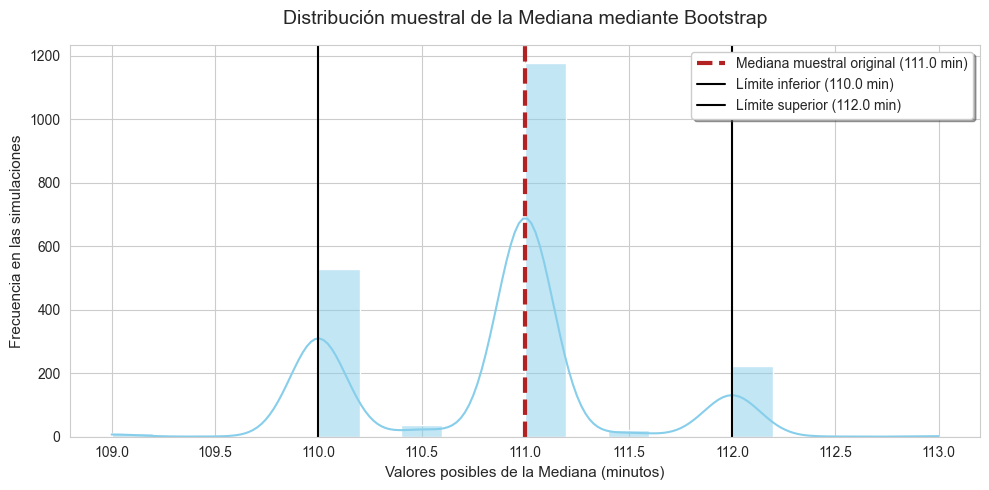

In [ ]:
plt.figure(figsize=(10, 5))

# Usamos un color de fondo más suave para que contrasten las líneas
sns.histplot(medianas_simuladas, kde=True, color='skyblue', bins=20, edgecolors='white')

# Línea de la Mediana Original - La hacemos más gruesa y llamativa
plt.axvline(np.median(duracion_drama), color='firebrick', linestyle='--', linewidth=3, 
            label=f'Mediana muestral original ({np.median(duracion_drama):.1f} min)')

# Límites del Intervalo de Confianza - Usamos líneas continuas más delgadas para diferenciarlas
plt.axvline(inf, color='black', linestyle='-', linewidth=1.5, 
            label=f'Límite inferior ({inf:.1f} min)')
plt.axvline(sup, color='black', linestyle='-', linewidth=1.5, 
            label=f'Límite superior ({sup:.1f} min)')

plt.title("Distribución muestral de la Mediana mediante Bootstrap", fontsize=14, pad=15)
plt.xlabel("Valores posibles de la Mediana (minutos)", fontsize=11)
plt.ylabel("Frecuencia en las simulaciones", fontsize=11)

# Movemos la leyenda fuera del gráfico o en una esquina limpia para que no tape las barras
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

## Escalando el experimento: Comparación Multi-Género Automatizada

Hasta este punto, evaluamos manualmente la incertidumbre de la mediana solo para el género de *Drama*. Sin embargo, en el análisis de datos real, necesitamos comparar múltiples categorías simultáneamente para extraer patrones de comportamiento.

En lugar de copiar y pegar el bloque de código anterior para cada categoría, aprovecharemos el poder algorítmico de Python. Construiremos un bucle `for` que recorra los géneros principales de nuestra base de datos (`Drama`, `Action`, `Comedy`), extraiga sus vectores de datos limpios, ejecute la función de Bootstrap en paralelo y empaquete los resultados directamente en un objeto `pd.DataFrame` para su visualización tabular inmediata.

In [8]:
# 1. Definimos la lista de géneros que deseamos contrastar
generos_a_estudiar = ['Drama', 'Action', 'Comedy']
bootstrap_resultados = []

# 2. Iteramos sobre cada categoría utilizando la función bootstrap_mediana
for genero in generos_a_estudiar:
    # Extraemos el subconjunto de datos desde movies_limpio
    grupo = df.loc[df['GeneroPrincipal'] == genero, 'Runtime'].dropna().values
    
    # Desempaquetamos los 3 elementos que devuelve tu función bootstrap_mediana
    replicas, li, ls = bootstrap_mediana(grupo, num_replicas=2000, confianza=95)
    
    # Calculamos el valor central (la mediana de las réplicas) para reportar en la tabla
    mediana_centro = np.median(replicas)
    
    # Estructuramos el diccionario con los resultados formateados
    bootstrap_resultados.append({
        'Género Principal': genero,
        'Mediana Bootstrap (min)': round(mediana_centro, 2),
        'IC Inferior (Percentil 2.5)': round(li, 2),
        'IC Superior (Percentil 97.5)': round(ls, 2)
    })

# 3. Desplegamos la tabla consolidada
tabla_inferencial = pd.DataFrame(bootstrap_resultados)
tabla_inferencial


,Género Principal,Mediana Bootstrap (min),IC Inferior (Percentil 2.5),IC Superior (Percentil 97.5)
0,Drama,111.0,110.0,112.0
1,Action,109.0,108.0,110.0
2,Comedy,100.0,100.0,101.0


## ¿Qué nos dice esta tabla?

Observen detenidamente los Intervalos de Confianza (IC) desplegados en la tabla. Esta estructura nos permite evaluar la incertidumbre de un solo vistazo:

1. **Robustez ante el azar:** Si los rangos calculados por el Bootstrap son muy estrechos, significa que la métrica de ese género es altamente estable y no cambiará drásticamente aunque recopilemos más películas en el futuro.
2. **El traslape de intervalos:** Observen si el Intervalo de Confianza de un género (por ejemplo, *Drama*) se cruza o se encima numéricamente con el de otro (como *Comedy* o *Action*). 
   * Si los intervalos se traslapan demasiado, significa que la diferencia entre sus medianas podría ser pura casualidad del azar del muestreo.
   * Si no se cruzan en absoluto, tenemos indicios visuales muy fuertes de que un género dura realmente más que el otro en la población general.
3. El intervalo de confianza (IC) no es garantía absoluta. El IC del 95% no asegura que la mediana real esté en ese rango con certeza, sino que en el 95% de los experimentos similares sí lo estará.

### Lo que viene:
¿Cómo podemos medir de forma matemática y formal si estas diferencias de comportamiento entre grupos son verdaderamente significativas, o si son solo un espejismo del azar? ¿Cómo tomamos una decisión algorítmica estandarizada para rechazar una suposición?

Responder a esta pregunta con rigor científico requiere definir hipótesis, niveles de significancia y reglas de decisión.

- Comparaciones entre ICs deben hacerse con cuidado. Aunque los IC de "Drama" y "Comedy" no se traslapan, lo que sugiere una diferencia significativa en la mediana, esta comparación no reemplaza una prueba formal().
- Bootstrap de la mediana ≠ prueba de hipótesis. No es lo mismo que obtener un p-valor. Bootstrap te ayuda a estimar un parámetro y su variabilidad, pero no te dice directamente si hay diferencia significativa (aunque se puede extender para eso).

### Reto en clase: Estimando la duración del Cine de Studio Ghibli

Studio Ghibli es mundialmente famoso por cuidar de forma artesanal cada detalle de sus producciones de animación. El equipo de distribución de nuestra plataforma de streaming quiere saber de manera robusta cuál es la **mediana de duración** de las películas dirigidas por el maestro **Hayao Miyazaki** para planificar bloques de transmisión eficientes.

Como nuestra base de datos es solo una muestra de la historia del cine y los tiempos de edición varían, utilizaremos la fuerza bruta computacional del **Bootstrap** para cuantificar la incertidumbre de la mediana sin asumir que los datos siguen una distribución normal tradicional.

#### Instrucciones del ejercicio:
1. **Cargar y Filtrar los datos:** Carguen el archivo `Ghibli_2.csv` en un nuevo DataFrame. Filtren las filas donde el `director` sea exactamente `'Hayao Miyazaki'` y extraigan la columna de duración `running_time`. Asegúrense de limpiar nulos usando `.dropna().values`.
2. **Construir el bucle de Bootstrap:** Programen un bucle `for` que ejecute **2,000 iteraciones**. En cada iteración, usen `resample()` (la función de la librería *scikit-learn* que vimos la clase pasada) para obtener una muestra con reemplazo del mismo tamaño que la original, calculen su **mediana** (`np.median`) y guárdenla en una lista llamada `medianas_ghibli`.
3. **Calcular el Intervalo de Confianza:** Obtengan los percentiles 2.5 y 97.5 de `medianas_ghibli` usando `np.percentile` para construir el intervalo de confianza del 95%.
4. **Visualización:** Grafiquen el histograma de las medianas simuladas con su curva de densidad (KDE). Pinten líneas verticales discontinuas para delimitar los límites del intervalo y una línea continua central para la mediana de las simulaciones.

#### Pregunta de reflexión:
* Observando el Intervalo de Confianza obtenido en la gráfica: Si la plataforma de streaming necesita asegurar con un 95% de certeza el rango de tiempo que dura una producción típica de Miyazaki, ¿cuáles serían los minutos mínimos y máximos que deberíamos reportar? ¿Qué ventaja tuvo usar Bootstrap en lugar de dar simplemente la mediana directa y "tibia" de la base de datos original?